# EDA for E-commerce data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [15]:
df = pd.read_csv(
    '../data/data.csv', 
    encoding="ISO-8859-1", 
    parse_dates=['InvoiceDate'],
)
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [17]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


* I guess both quantity and unitprice distributions are skewed

In [18]:
df['Country'].unique

<bound method Series.unique of 0         United Kingdom
1         United Kingdom
2         United Kingdom
3         United Kingdom
4         United Kingdom
               ...      
541904            France
541905            France
541906            France
541907            France
541908            France
Name: Country, Length: 541909, dtype: str>

### Check:
- seasonality
- customers (count orders/overall expenses)
- stock's (quantity of selled good)
- countries ofc
- **NAN's/missing values**

**What are we trying to predict?**  
probably *revenue* for the future timeframe (week/month) 
then the training data **SHOULD NOT** contain  
neither Quantity, StockCode, Description nor UnitPrice as the model  
would be able to implicitly infer Revenue from them

**NOTES:**
* might there be a correlation between Country and UnitPrice because of 
delivery prices?
* we need a correlation heatmap for revenue

In [21]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [39]:
# since we only have the data for a year
# we'll check seasonality for every month
# and for each quarter
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Quarter'] = df['InvoiceDate'].dt.to_period('Q')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,month,Month,Quarter
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12,2010Q4
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12,2010Q4
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12,2010Q4
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12,2010Q4
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12,2010Q4


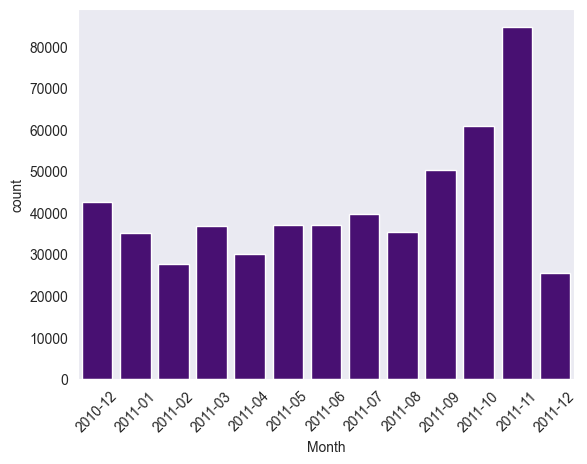

In [36]:
plt.xticks(rotation=45)
with sns.axes_style('dark'):
    ax = sns.countplot(df, x='Month', color='indigo')

<Axes: xlabel='Quarter', ylabel='count'>

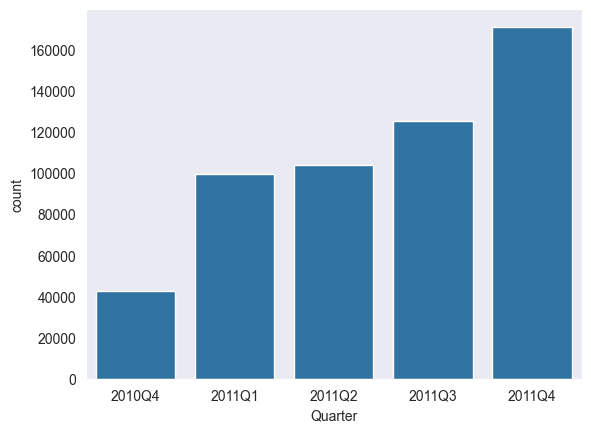

In [40]:
# Q1-Q4
sns.countplot(df, x='Quarter')

In [84]:
df['CustomerID'] = df['CustomerID'].astype('Int64')
df['StockCode'] = df['StockCode'].astype('category')  # ~4000 stocks
df['Country'] = df['Country'].astype('category')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  category      
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  Int64         
 7   Country      541909 non-null  category      
 8   Revenue      541909 non-null  float64       
 9   month        541909 non-null  period[M]     
 10  Month        541909 non-null  period[M]     
 11  Quarter      541909 non-null  period[Q-DEC] 
dtypes: Int64(1), category(2), datetime64[us](1), float64(2), int64(1), period[M](2), period[Q-DEC](1), str(2)
memory usage: 43.6 MB


In [55]:
df.duplicated().sum()

np.int64(5268)

In [56]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
Revenue             0
month               0
Month               0
Quarter             0
dtype: int64

<Axes: >

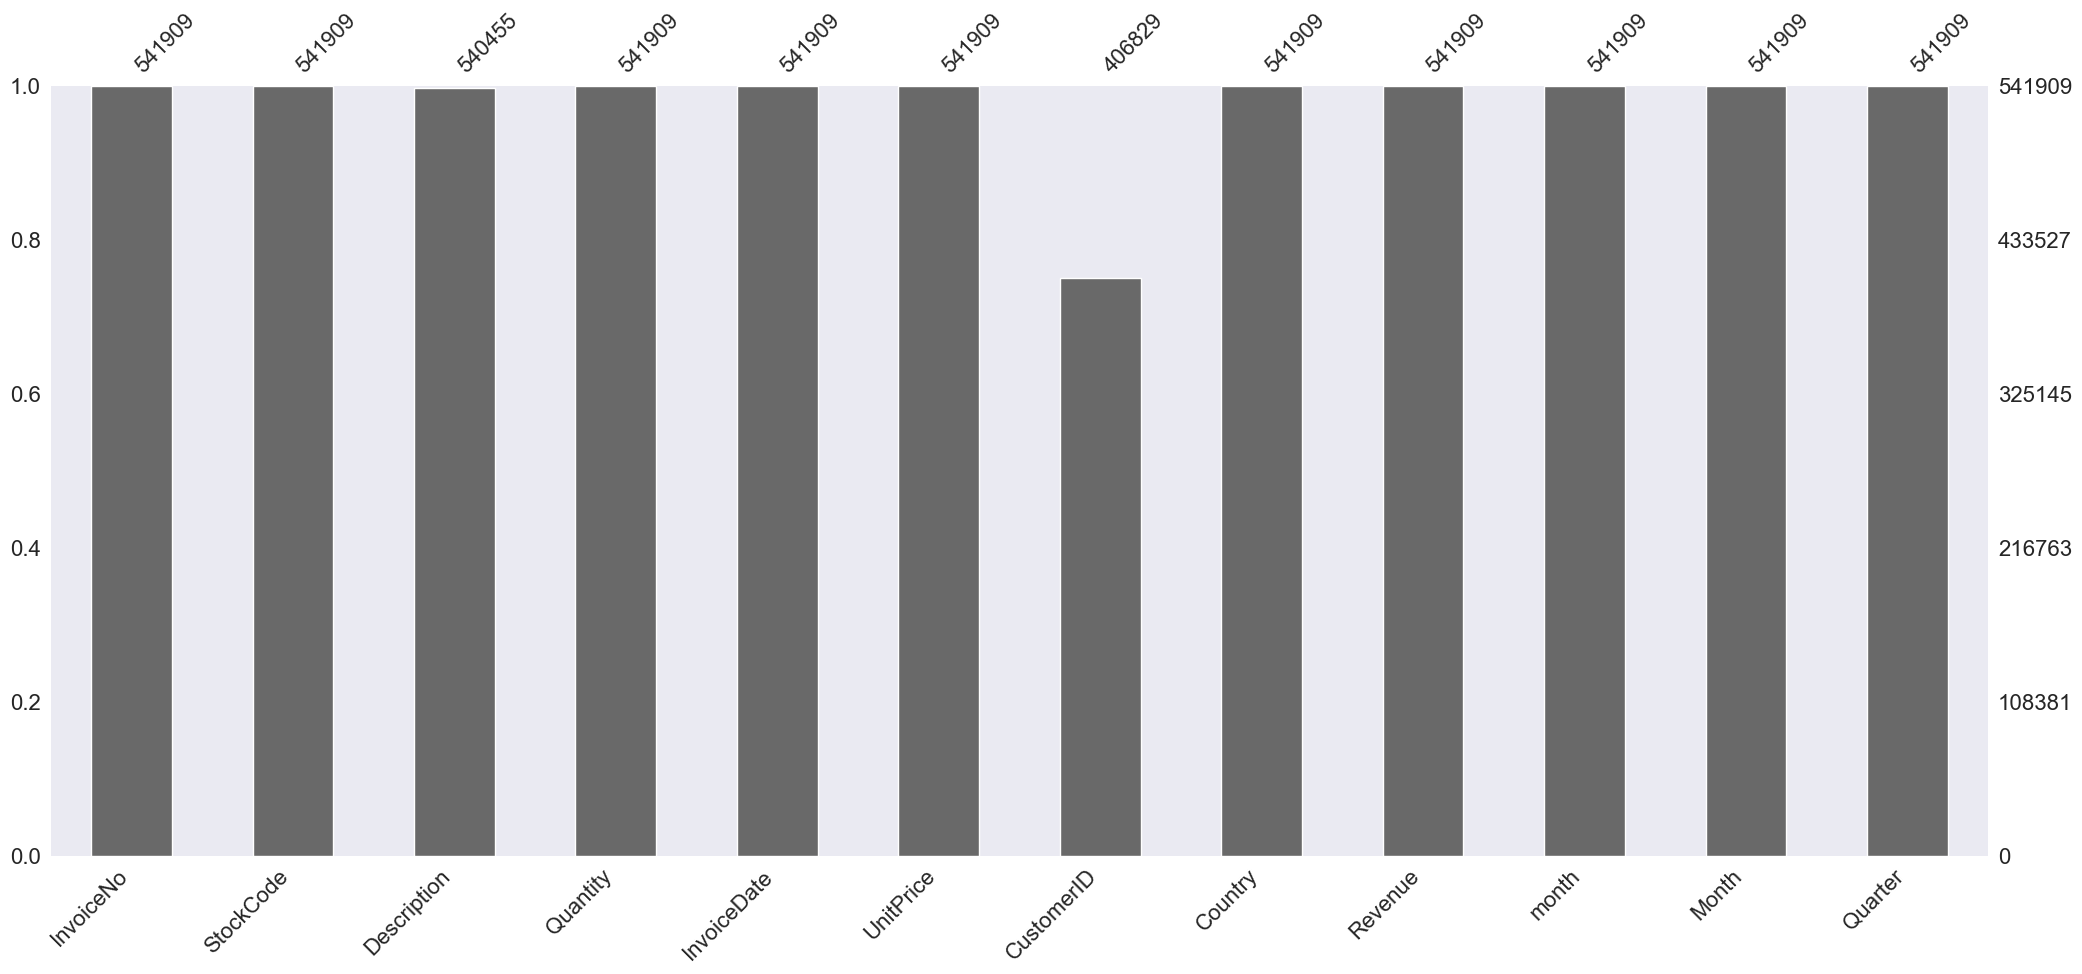

In [ ]:
# Visualizing missing data
import missingno as msno
msno.bar(df)

since we miss a lot of customer id values, I propose imputing them with a "missing" flag (just deleting 120k+ records is loosing a lot of data, especially in time-series)

In [77]:
top_stocks = df.groupby("StockCode")["Quantity"].sum().sort_values(ascending=False).head(100)
top_stocks

StockCode
22197     56450
84077     53847
85099B    47363
85123A    38830
84879     36221
          ...  
22988      8878
21985      8803
82482      8773
21094      8758
22909      8728
Name: Quantity, Length: 100, dtype: int64

In [101]:
df['RevenueByCountry'] = df.groupby(by='Country')['Revenue'].transform('sum')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,month,Month,Quarter,RevenueByCountry
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010-12,2010Q4,8187806.364
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12,2010Q4,8187806.364
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010-12,2010Q4,8187806.364
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12,2010Q4,8187806.364
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12,2010Q4,8187806.364


<Axes: xlabel='RevenueByCountry', ylabel='Country'>

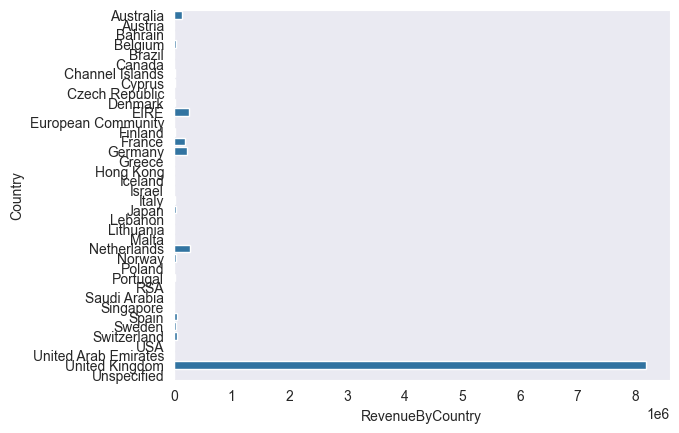

In [107]:
revenue_summary = df.groupby('Country')['RevenueByCountry'].first().reset_index()
revenue_summary.columns = ['Country', 'RevenueByCountry']
sns.barplot(revenue_summary, x='RevenueByCountry', y='Country')

UK has 8M+ of revenue. Does that mean that the average purchase price is higher?

In [116]:
avg_purchase = df.groupby('Country')['Revenue'].mean()
avg_purchase.sort_values(ascending=False).head(10)

Country
Netherlands    120.059696
Australia      108.877895
Japan           98.716816
Sweden          79.211926
Denmark         48.247147
Lithuania       47.458857
Singapore       39.827031
Lebanon         37.641778
Brazil          35.737500
Hong Kong       35.128611
Name: Revenue, dtype: float64

Netherlands, Australia and Japan have the highest avg purchase price!

TODO: analyze weekdays, holidays, black friday, avg purchase vs first time

## Conclusions:

- Remove "debt adjustments" 
- Replace NaNs in ID and Description with "missing" flags
- Feature engineering:
    - isQ4/is holidary period
    - RFM -> days since the last purchase, amount of purchases, average order value, first purchase
    - cumulative features
        - cumulative sum
        - cumulative sum for client
        - cumulative sum for country
    - rolling stats
        - mean/median/std for 7/30 days
        - for stock code/client/country
    - lag
        - sales/avg sale/transactions count | 7/30
    - cyclic (sin(month)/sin(weekday))
    - hour  

**pay attention to data leakage!**
**no global averages, train/val splits**